In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
df = pd.read_csv('data/airport_traffic_merged.csv')

In [3]:
display(df. info())
display(df.sample(5))
df = df.drop(columns=['FLT_DEP_IFR_2','FLT_ARR_IFR_2','FLT_TOT_IFR_2','MONTH_MON'])
display(df.describe().round())
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'])

<class 'pandas.DataFrame'>
RangeIndex: 822581 entries, 0 to 822580
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   YEAR           822581 non-null  int64  
 1   MONTH_NUM      822581 non-null  int64  
 2   MONTH_MON      822581 non-null  str    
 3   FLT_DATE       822581 non-null  str    
 4   APT_ICAO       822581 non-null  str    
 5   APT_NAME       822581 non-null  str    
 6   STATE_NAME     822581 non-null  str    
 7   FLT_DEP_1      822581 non-null  int64  
 8   FLT_ARR_1      822581 non-null  int64  
 9   FLT_TOT_1      822581 non-null  int64  
 10  FLT_DEP_IFR_2  240235 non-null  float64
 11  FLT_ARR_IFR_2  240235 non-null  float64
 12  FLT_TOT_IFR_2  240235 non-null  float64
dtypes: float64(3), int64(5), str(5)
memory usage: 81.6 MB


None

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
329420,2021,12,DEC,2021-12-16,LFBE,Bergerac-Roumanière,France,2,2,4,NaN,NaN,NaN
552242,2023,11,NOV,2023-11-28,ENBR,Bergen,Norway,128,131,259,126.0,127.0,253.0
136572,2020,3,MAR,2020-03-13,EPLB,Lublin,Poland,3,3,6,NaN,NaN,NaN
475311,2023,3,MAR,2023-03-28,EGLF,Farnborough,United Kingdom,35,34,69,NaN,NaN,NaN
771940,2025,10,OCT,2025-10-23,GCTS,Tenerife Sur - Reina Sofia,Spain,104,105,209,102.0,104.0,206.0


,YEAR,MONTH_NUM,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1
count,822581.0,822581.0,822581.0,822581.0,822581.0
mean,2022.0,6.0,62.0,62.0,123.0
std,2.0,3.0,108.0,108.0,217.0
min,2019.0,1.0,0.0,0.0,0.0
25%,2020.0,3.0,5.0,5.0,10.0
50%,2022.0,6.0,17.0,17.0,33.0
75%,2024.0,9.0,69.0,69.0,139.0
max,2026.0,12.0,915.0,844.0,1688.0


In [4]:
display(df.duplicated().value_counts())
df[df.duplicated(keep=False)]
df = df.drop_duplicates()

False    822580
True          1
Name: count, dtype: int64

In [5]:
df.to_csv('data/clean/airport_clean.csv')

---
---

In [6]:
airport = pd.read_csv("data/clean/airport_clean.csv")

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

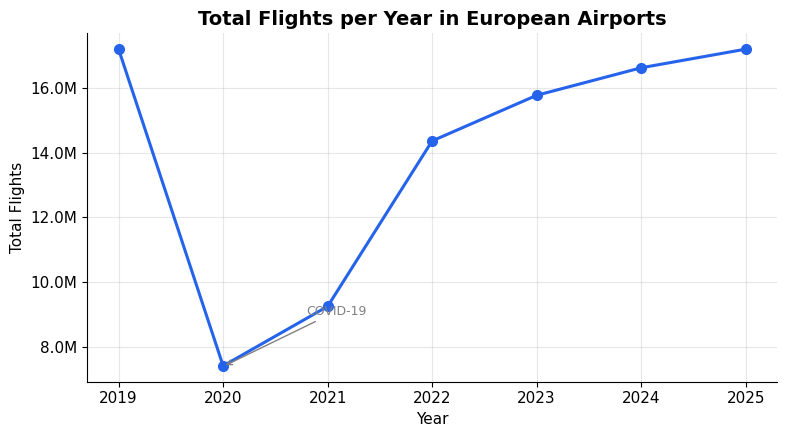

In [7]:
# ============================================================
# A1 – Total flights per year (COVID drop and recovery)
# ============================================================
# Exclude 2026 (incomplete year)
flights_year = (airport[airport["YEAR"] <= 2025]
                .groupby("YEAR")["FLT_TOT_1"].sum().reset_index())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(flights_year["YEAR"], flights_year["FLT_TOT_1"], marker="o",
        color="#2563EB", linewidth=2.2, markersize=7)
ax.set_title("Total Flights per Year in European Airports",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Total Flights")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.annotate("COVID-19", xy=(2020, 7.4e6), fontsize=9,
            xytext=(2020.8, 9e6),
            arrowprops=dict(arrowstyle="->", color="grey"), color="grey")
plt.tight_layout()
plt.show()

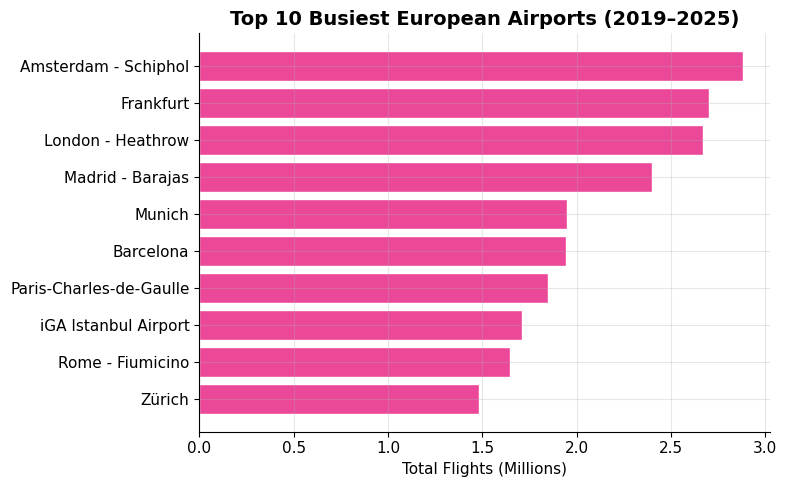

In [8]:
# ============================================================
# A2 – Top 10 busiest airports (total flights 2019–2025)
# ============================================================
top_apt = (airport[airport["YEAR"] <= 2025]
           .groupby("APT_NAME")["FLT_TOT_1"]
           .sum()
           .nlargest(10)
           .sort_values()
           .reset_index())

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_apt["APT_NAME"], top_apt["FLT_TOT_1"] / 1e6,
        color="#EC4899", edgecolor="white")
ax.set_title("Top 10 Busiest European Airports (2019–2025)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Total Flights (Millions)")
plt.tight_layout()
plt.show()

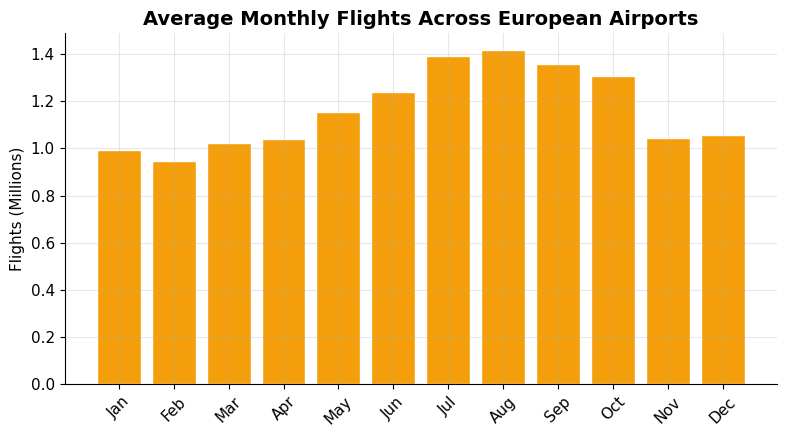

In [9]:
# ============================================================
# A3 – Monthly seasonality (avg flights per month, all years)
# ============================================================
# Use only full years (2019–2025 excluding 2026)
monthly = (airport[airport["YEAR"].between(2019, 2025)]
           .groupby(["YEAR", "MONTH_NUM"])["FLT_TOT_1"]
           .sum()
           .reset_index()
           .groupby("MONTH_NUM")["FLT_TOT_1"]
           .mean()
           .reset_index())

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(monthly["MONTH_NUM"], monthly["FLT_TOT_1"] / 1e6,
       color="#F59E0B", edgecolor="white")
ax.set_title("Average Monthly Flights Across European Airports",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Flights (Millions)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=45)
plt.tight_layout()
plt.show()

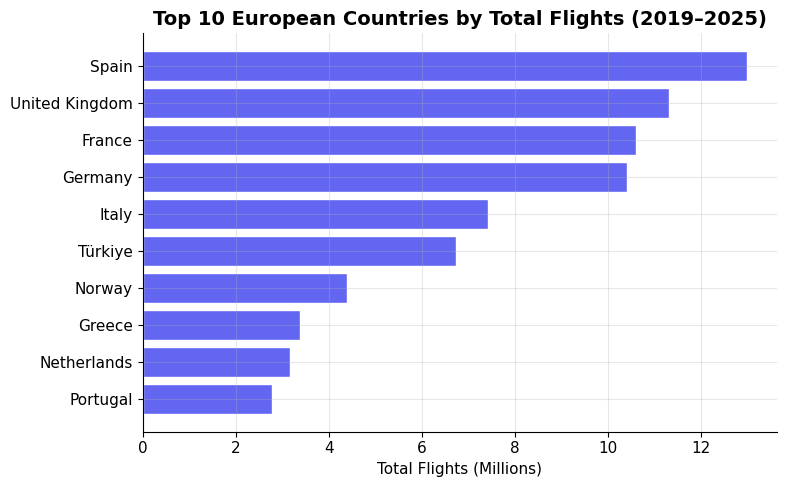

In [10]:
# ============================================================
# A4 – Top 10 countries by flights
# ============================================================
flights_country = (airport[airport["YEAR"] <= 2025]
                   .groupby("STATE_NAME")["FLT_TOT_1"]
                   .sum()
                   .nlargest(10)
                   .sort_values()
                   .reset_index())

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(flights_country["STATE_NAME"], flights_country["FLT_TOT_1"] / 1e6,
        color="#6366F1", edgecolor="white")
ax.set_title("Top 10 European Countries by Total Flights (2019–2025)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Total Flights (Millions)")
plt.tight_layout()
plt.show()

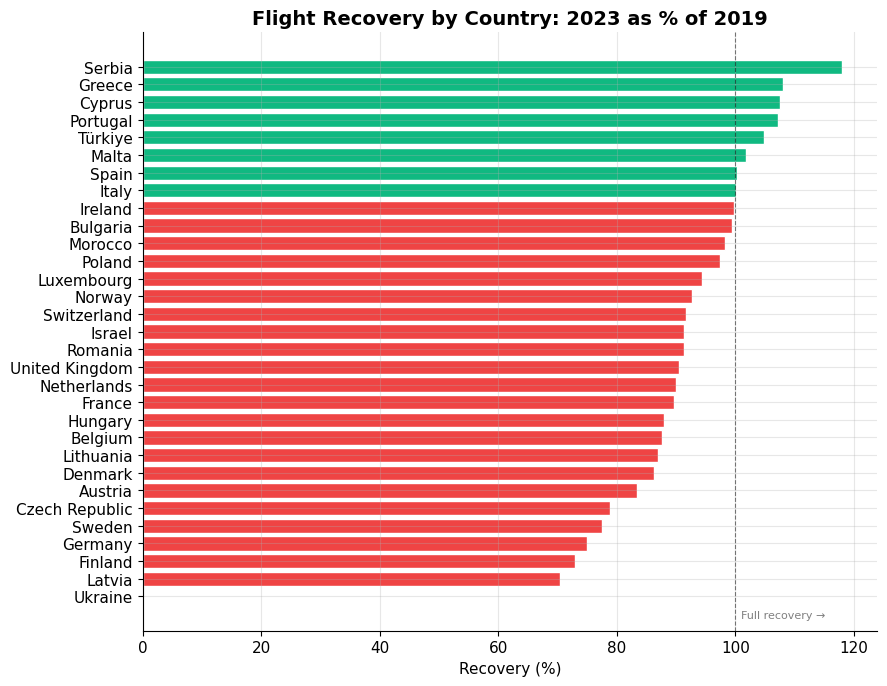

In [11]:
# ============================================================
# A5 – Post-COVID recovery by country (2023 flights as % of 2019)
# ============================================================
pre = airport[airport["YEAR"] == 2019].groupby("STATE_NAME")["FLT_TOT_1"].sum()
post = airport[airport["YEAR"] == 2023].groupby("STATE_NAME")["FLT_TOT_1"].sum()
recovery = ((post / pre) * 100).dropna().reset_index()
recovery.columns = ["STATE_NAME", "recovery_pct"]

# Keep only countries with meaningful traffic (>50k flights in 2019)
big_states = pre[pre > 50000].index
recovery = recovery[recovery["STATE_NAME"].isin(big_states)].sort_values("recovery_pct")

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#EF4444" if x < 100 else "#10B981" for x in recovery["recovery_pct"]]
ax.barh(recovery["STATE_NAME"], recovery["recovery_pct"], color=colors, edgecolor="white")
ax.axvline(100, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("Flight Recovery by Country: 2023 as % of 2019",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Recovery (%)")
ax.text(101, -1.2, "Full recovery →", fontsize=8, color="grey")
plt.tight_layout()
plt.show()